### PROBABILITY ANALYSIS

This notebook analyse the probability of picking RFI in the DME band as a function of time and  
frequency on Lband MeerKAT data. The data was extracted from  the KATHPRFI (Karoo Array    
Telescope   Historical Probability of Radio Frequency Interference) framework (Sihlangu et al., 2022).  


In [70]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
import re

In [159]:
YEARS         = list(range(2018, 2024))
THRESHOLD     = 0.3

DATE_DIM      = "date"          # name of the observation-date dimension
TIME_DIM      = "time"          # name of the hour-of-day dimension
FREQ_DIM      = "frequency"     # name of the frequency dimension

MONTH_NAMES   = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

CMAP_HEATMAP  = "inferno"       # colormap for freq–time heatmaps
CMAP_LINE     = "plasma"        # colormap for line plots


In [3]:
# 1. Define standard journal font sizes (in points)
FONT_SIZE_BASE = 10  # Matches typical manuscript body text
FONT_SIZE_SMALL = 8  # For tick labels and legends

# 2. Update Matplotlib configuration globally
plt.rcParams.update({
    'font.size': FONT_SIZE_BASE,          # Base font size for general text
    'axes.labelsize': FONT_SIZE_BASE,     # X and Y axis labels
    'axes.titlesize': FONT_SIZE_BASE + 2, # Subplot titles
    'xtick.labelsize': FONT_SIZE_SMALL,   # X-axis tick labels
    'ytick.labelsize': FONT_SIZE_SMALL,   # Y-axis tick labels
    'legend.fontsize': FONT_SIZE_SMALL,   # Legend font size
    'figure.titlesize': FONT_SIZE_BASE + 4,# Main figure title
    
    # Optional: Font families preferred by publishers (e.g., Times New Roman or STIX)
    'font.family': 'serif',
    'mathtext.fontset': 'stix'             # Matches LaTeX document typography
})


In [4]:
def combine(path) -> xr.DataArray:
    """
    Combine multiple observation files into a single 3D xarray.DataArray
    with dimensions corresponding to observation date, time of day,
    and frequency.

    The observation date is extracted from the Unix timestamp contained
    in each filename.

    Parameters
    ----------
    path : str
        Path to the text file containing the list of observation files.

    Returns
    -------
    xarray.DataArray
        A 3D DataArray containing the RFI probability as a function of
        observation date, time, and frequency with dimensions
        (observation_date, time, frequency).
    """

    zarr_file = [
    item for item in os.listdir(path)
    if os.path.isdir(os.path.join(path, item))
    and item.endswith(".zarr")
    ]

    data_array = []

    for file in zarr_file:
        
        # 1. open file and compute 1D result
        full_path = os.path.join(path, file)
        ds = xr.open_zarr(full_path, consolidated=False)
        da = ds["probability"]
        frequency = ds["frequency"]
        
        bandwidth = float(frequency[-1] - frequency[0])*1e-6
        spacing = 0.20893335342407227
        channel = int(bandwidth / spacing)
        
        if frequency.shape[0] > channel:
            # Convert Unix Timestamp in file name to UTC
            timestamp = int(re.search(r"\d{10}", file).group())
            time_utc = pd.to_datetime(timestamp, unit="s", utc=True)

            # Add observation dimension
            da = da.expand_dims(date=[time_utc])
            data_array.append(da)
        
        else:
            print(f"File in {full_path} has a bad shape")
    observation = xr.concat(data_array, dim ="date")

    return observation

In [157]:
def probability(data) -> xr.DataArray:
    """
    This function extract the probability as a function of time from dataset
    
    Parameters
    ----------
    data : xarray.Datasets
        Contains a 3D data (date, time, frequency) 

    Returns
    -------
    probability : xarray.dataArray
        RFI weighted probability as a function time
    """


    # Define weight from observation date duraition
    weights = data.notnull().sum(dim=["time", "frequency"])
    weighted_data = data.weighted(weights)


    # Probability as a function of time
    # Weighted average
    weighted_mean_prob = weighted_data.mean(dim=["date", "frequency"])

    weighted_std_prob = weighted_data.std(dim=["date", "frequency"])

    return weighted_mean_prob, weighted_std_prob




In [56]:
def plot(mean_prob, std, time, title):

    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(time, mean_prob, marker="o", label ='Mean')
    ax.set_xticks(np.arange(0,24,2))

    # Add the standard deviation band
    ax.fill_between(
        time, 
        mean_prob + std, 
        mean_prob - std, 
        color="blue", 
        alpha=0.2, 
        label="1 Std Dev"
    )
    ax.set_xlim(left=0, right=23)
    ax.grid(alpha=0.2)
    ax.set_xlabel("Time of Day (UTC)")
    ax.set_ylabel("Probability")
    ax.set_title(title)
    ax.legend()
    return fig

In [100]:
path = "/home/it/Documents/rfi/data/prob_time_freq_962_1213"
data = combine(path)
time = data["time"]
frequency = data["frequency"]*1e-6 # Frequency in MHz
date = data["date"]


# Define weight from observation date duraition
weights = data.notnull().sum(dim=["time", "frequency"])
weighted_data = data.weighted(weights)

# 68% confidence interval
lower = weighted_data.quantile(0.84, dim=("date","time"))
uper = weighted_data.quantile(0.16, dim=("date","time"))


### Time Analysis   

#### Daily analysis

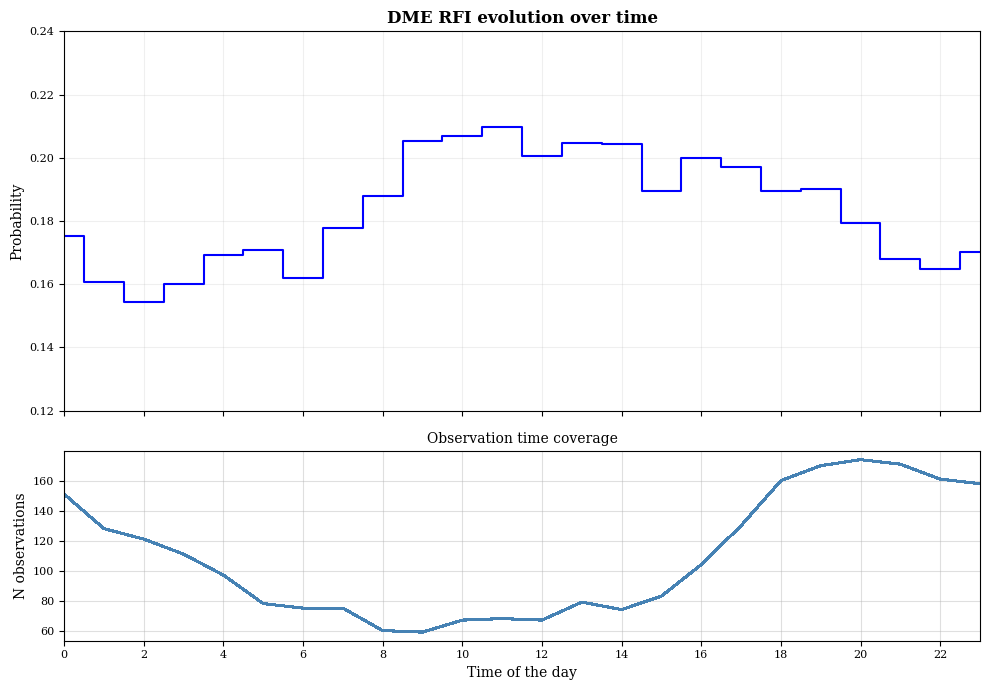

Total number of observations: 771


In [235]:
dme_weight_mean = probability(data)[0]
dme_weight_std  = probability(data)[1]
coverage        = data.notnull().sum(dim=["date"])

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1]})

# ── Top panel: RFI probability ───────────────────────────────────
axes[0].step(time, dme_weight_mean, where="mid", color="blue")
axes[0].set_yticks(np.arange(0.12, 0.25, 0.02))
axes[0].grid(alpha=0.2)
axes[0].set_ylabel("Probability")
axes[0].set_title("DME RFI evolution over time", fontsize=12, fontweight="bold")

# ── Bottom panel: observation coverage ───────────────────────────
axes[1].plot(time, coverage, color="steelblue")
axes[1].grid(alpha=0.4)
axes[1].set_xlabel("Time of the day")
axes[1].set_ylabel("N observations")
axes[1].set_title("Observation time coverage", fontsize=10)

axes[1].set_xticks(np.arange(0, 24, 2))
axes[1].set_xlim(left=0, right=23)

plt.tight_layout()
plt.savefig("daily_rfi_evolution.png")
plt.show()


print(f"Total number of observations: {data.shape[0]}")

In [230]:
total_obs = []


for mo in range(1,13):
    mask    = data["month"] == mo
    total_obs.append(data.isel({DATE_DIM: mask}).sizes[DATE_DIM])

total_obs

[193, 61, 56, 61, 40, 63, 22, 6, 27, 61, 50, 131]

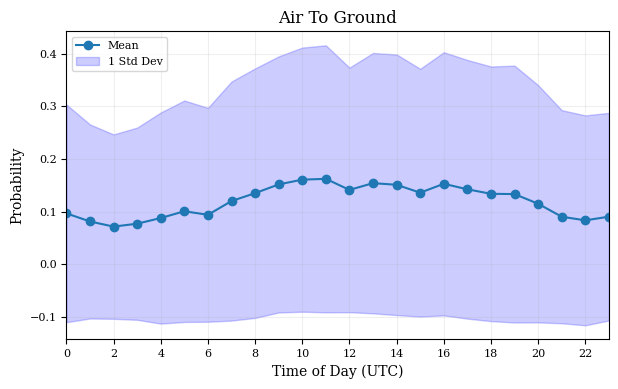

In [58]:
air_gnd = data.sel(frequency=slice(1026*1e6, 1150*1e6))

air_gnd_mean = probability(air_gnd)[0]
air_gnd_std = probability(air_gnd)[1]

figure = plot(air_gnd_mean, air_gnd_std, time, "Air To Ground")



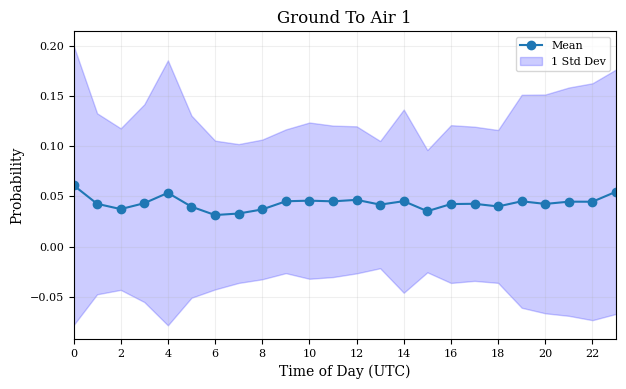

In [59]:
gnd_air1 = data.sel(frequency=slice(932*1e6, 1025*1e6))

gnd_air1_mean = probability(gnd_air1)[0]
gnd_air1_std = probability(gnd_air1)[1]

figure = plot(gnd_air1_mean, gnd_air1_std, time, "Ground To Air 1")


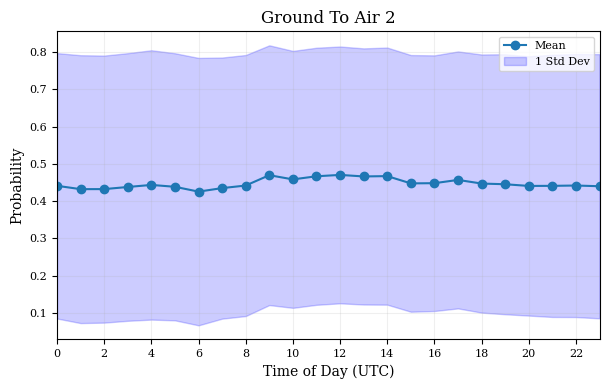

In [60]:
gnd_air2 = data.sel(frequency=slice(1151*1e6, 1213*1e6))

gnd_air2_mean = probability(gnd_air2)[0]
gnd_air2_std = probability(gnd_air2)[1]

figure = plot(gnd_air2_mean, gnd_air2_std, time, "Ground To Air 2")


#### Monthly Analysis

In [181]:
data = data.assign_coords(
        year  =("date", pd.DatetimeIndex(data["date"].values).year),
        month =("date", pd.DatetimeIndex(data["date"].values).month),
    )

data

<xarray.DataArray 'probability' (date: 771, time: 24, frequency: 1201)> Size: 178MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(771, 24, 1201))
Coordinates:
  * date       (date) datetime64[s, UTC] 6kB 2022-05-27 01:37:20+00:00 ... 20...
    year       (date) int32 3kB 2022 2023 2023 2023 2018 ... 2020 2023 2018 2022
    month      (date) int32 3kB 5 1 1 1 10 6 12 2 12 1 ... 1 6 1 1 6 9 11 1 9 2
  * time       (time) int64 192B 0 1 2 3 4 5 6 7 8 ... 16 17 18 19 20 21 22 23
  * frequency  (frequency) float64 10kB 9.622e+08 9.624e+08 ... 1.213e+09

In [ ]:
def plot_seasonal_cycle(da: xr.DataArray):
    """Overall mean RFI probability per calendar month with inter-annual spread.
    Uses weighted mean across years, weighted by number of observations per month.
    """
    means, stds = [], []

    for mo in range(1, 13):
        yr_means  = []
        yr_weights = []

        for yr in YEARS:
            mask   = (da["month"] == mo) & (da["year"] == yr)
            subset = da.isel({DATE_DIM: mask})
            n_obs  = subset.sizes[DATE_DIM]

            if n_obs > 0:
                yr_means.append(float(subset.mean()))
                yr_weights.append(n_obs)

        if yr_means:
            yr_means   = np.array(yr_means)
            yr_weights = np.array(yr_weights)

            # Weighted mean across years
            weighted_mean = np.average(yr_means, weights=yr_weights)

            # Weighted std across years
            weighted_var = np.average((yr_means - weighted_mean) ** 2, weights=yr_weights)
            weighted_std = np.sqrt(weighted_var)

            means.append(weighted_mean)
            stds.append(weighted_std)
        else:
            means.append(np.nan)
            stds.append(np.nan)

    means  = np.array(means)
    stds   = np.array(stds)
    months = np.arange(1, 13)

    fig, axes = plt.subplots(2, 1, figsize=(10, 7),
                              gridspec_kw={"height_ratios": [3, 1]})

    # ── Top panel: weighted mean ± std 
    axes[0].plot(months, means, "o-", color="blue", lw=2.2, ms=7,
                 label="Weighted inter-annual mean")
    axes[0].fill_between(months, means - stds, means + stds,
                         alpha=0.25, color="blue", label="±1 std (weighted)")
    axes[0].set_xticks(months)
    axes[0].set_xticklabels(MONTH_NAMES)
    axes[0].set_ylabel("Mean RFI Fraction")
    axes[0].set_title("Monthly DME RFI Evolution (2018-2023)",
                       fontsize=13, fontweight="bold")
    axes[0].set_ylim(0, None)
    axes[0].grid(True, ls="--", alpha=0.4)
    axes[0].legend()

    # ── Bottom panel: total observations per month 
    total_obs = []
    for mo in range(1, 13):
        mask    = da["month"] == mo
        total_obs.append(da.isel({DATE_DIM: mask}).sizes[DATE_DIM])

    axes[1].bar(months, total_obs, color="steelblue", alpha=0.8, width=0.6)
    axes[1].set_xticks(months)
    axes[1].set_xticklabels(MONTH_NAMES)
    axes[1].set_ylabel("N observations")
    axes[1].set_xlabel("Month")
    axes[1].grid(True, ls="--", alpha=0.4, axis="y")
    axes[1].set_title("Total observations per month (all years)", fontsize=10)

    plt.tight_layout()
    plt.show()

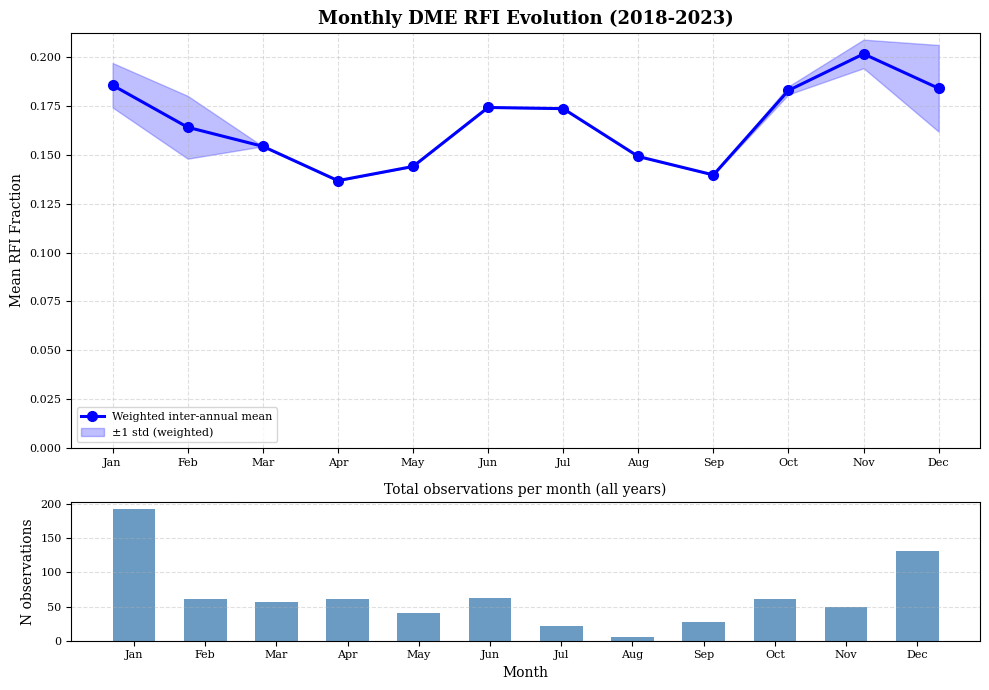

In [183]:
plot_seasonal_cycle(data)

In [202]:
def plot_yearly_analysis(da: xr.DataArray):
    """Yearly mean RFI fraction with weighted average across months,
    weighted by number of observations per month.
    """
    yr_means   = []
    yr_stds    = []
    yr_weights = []

    for yr in YEARS:
        mask   = da["year"] == yr
        da_yr  = da.isel({DATE_DIM: mask})
        n_obs  = da_yr.sizes[DATE_DIM]

        if n_obs > 0:
            # Weighted mean across months within this year
            mo_means   = []
            mo_weights = []

            for mo in range(1, 13):
                mo_mask   = da_yr["month"] == mo
                da_mo     = da_yr.isel({DATE_DIM: mo_mask})
                n_mo_obs  = da_mo.sizes[DATE_DIM]

                if n_mo_obs > 0:
                    mo_means.append(float(da_mo.mean()))
                    mo_weights.append(n_mo_obs)

            if mo_means:
                mo_means   = np.array(mo_means)
                mo_weights = np.array(mo_weights)

                # Weighted mean and std across months
                w_mean = np.average(mo_means, weights=mo_weights)
                w_std  = np.sqrt(np.average((mo_means - w_mean) ** 2, weights=mo_weights))

                yr_means.append(w_mean)
                yr_stds.append(w_std)
                yr_weights.append(n_obs)

                print(f"{yr}: {n_obs:4d} obs | mean = {w_mean:.4f} | std = {w_std:.4f}")
        else:
            yr_means.append(np.nan)
            yr_stds.append(np.nan)
            yr_weights.append(0)
            print(f"{yr}: no data")

    yr_means   = np.array(yr_means)
    yr_stds    = np.array(yr_stds)
    yr_weights = np.array(yr_weights)

    fig, axes = plt.subplots(2, 1, figsize=(10, 7),
                              gridspec_kw={"height_ratios": [3, 1]})

    # ── Top panel: yearly weighted mean ± std 
    axes[0].plot(YEARS, yr_means, "o-", color="blue", lw=2.2,
                 ms=8, label="Weighted yearly mean")
    axes[0].fill_between(YEARS,
                         yr_means - yr_stds,
                         yr_means + yr_stds,
                         alpha=0.25, color="blue", label="±1 std (weighted)")

    # Trend line
    valid = ~np.isnan(yr_means)
    if valid.sum() > 1:
        z    = np.polyfit(np.array(YEARS)[valid], yr_means[valid], 1)
        p    = np.poly1d(z)
        axes[0].plot(YEARS, p(YEARS), "--", color="red", lw=1.5,
                     label=f"Trend ({z[0]:+.4f}/yr)")

    axes[0].set_xticks(YEARS)
    axes[0].set_ylabel("Mean RFI Fraction")
    axes[0].set_title("Yearly DME RFI Evolution", fontsize=13, fontweight="bold")
    axes[0].set_ylim(0, None)
    axes[0].grid(True, ls="--", alpha=0.4)
    axes[0].legend()

    # ── Middle panel: number of observations per year 
    axes[1].bar(YEARS, yr_weights, color="steelblue", alpha=0.8, width=0.6)
    axes[1].set_xticks(YEARS)
    axes[1].set_ylabel("N observations")
    axes[1].set_title("Total observations per year", fontsize=10)
    axes[1].grid(True, ls="--", alpha=0.4, axis="y")

    # ── Bottom panel: weighted std per year (spread/variability) 
    # axes[2].bar(YEARS, yr_stds, color="darkorange", alpha=0.8, width=0.6)
    # axes[2].set_xticks(YEARS)
    # axes[2].set_xlabel("Year")
    # axes[2].set_ylabel("Weighted Std")
    # axes[2].set_title("Inter-month variability per year", fontsize=10)
    # axes[2].grid(True, ls="--", alpha=0.4, axis="y")

    plt.tight_layout()
    plt.show()

2018:  174 obs | mean = 0.1731 | std = 0.0179
2019:    8 obs | mean = 0.1876 | std = 0.0000
2020:   63 obs | mean = 0.1761 | std = 0.0198
2021:   64 obs | mean = 0.1990 | std = 0.0224
2022:  293 obs | mean = 0.1614 | std = 0.0233
2023:  169 obs | mean = 0.1818 | std = 0.0041


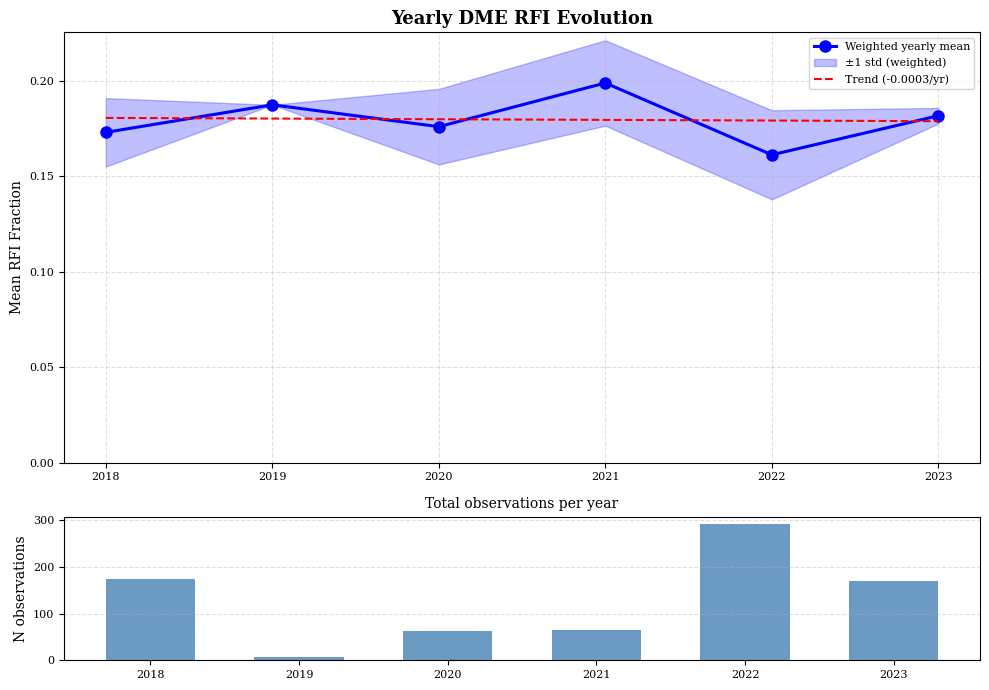

In [203]:
plot_yearly_analysis(data)

In [ ]:
def monthly_mean_by_year(da: xr.DataArray) -> dict:
    """
    Returns a nested dict:
        result[year][month] = DataArray(time, frequency)  ← mean over obs dates
    """
    result = {}
    for yr in YEARS:
        result[yr] = {}
        yr_mask = da["year"] == yr
        da_yr = da.isel({"date": yr_mask})
        for mo in range(1, 13):
            mo_mask = da_yr["month"] == mo
            da_mo = da_yr.isel({"date": mo_mask})
            if da_mo.sizes["date"] == 0:
                result[yr][mo] = None
            else:
                result[yr][mo] = da_mo.mean(dim="date")
    return result


def overall_monthly_mean(da: xr.DataArray) -> dict:
    """
    Mean over ALL years per calendar month → dict[month] = DataArray(time, frequency)
    """
    result = {}
    for mo in range(1, 13):
        mo_mask = da["month"] == mo
        da_mo = da.isel({"date": mo_mask})
        result[mo] = da_mo.mean(dim="date") if da_mo.sizes["date"] > 0 else None
    return result


def flagged_fraction(da: xr.DataArray, threshold: float = THRESHOLD) -> xr.DataArray:
    """
    For each (date), compute fraction of (time x frequency) pixels above threshold.
    Then group by year-month.
    """
    flagged = (da > threshold).mean(dim=["time", "frequency"])   # shape: (date,)
    dates   = pd.DatetimeIndex(da["date"].values)
    ym      = pd.PeriodIndex(dates, freq="M")
    df = pd.DataFrame({"ym": ym, "flagged": flagged.values})
    monthly = df.groupby("ym")["flagged"].mean().reset_index()
    monthly["year"]  = monthly["ym"].dt.year
    monthly["month"] = monthly["ym"].dt.month
    return monthly


In [142]:
def plot_monthly_time_evolution(monthly_by_year: dict, times: np.ndarray):
    fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharey=True)
    fig.suptitle("RFI Probability – Time-of-Day Profile per Month\n(frequency-averaged)",
                 fontsize=15, fontweight="bold", y=1.01)

    cmap   = plt.get_cmap(CMAP_LINE, len(YEARS))
    colors = {yr: cmap(i) for i, yr in enumerate(YEARS)}

    for ax, mo in zip(axes.flat, range(1, 13)):
        for yr in YEARS:
            da_mo = monthly_by_year[yr][mo]
            if da_mo is None:
                continue
            profile = da_mo.mean(dim=FREQ_DIM).values
            ax.plot(times, profile, label=str(yr), color=colors[yr], lw=1.4, alpha=0.85)

        ax.set_title(MONTH_NAMES[mo - 1], fontweight="bold")
        ax.set_xlabel("Hour (UTC)")
        ax.set_xlim(0, 24)
        ax.set_ylim(0, 1)
        ax.xaxis.set_major_locator(MultipleLocator(6))
        ax.xaxis.set_minor_locator(MultipleLocator(3))
        ax.grid(True, which="major", ls="--", alpha=0.4)
        ax.axhline(THRESHOLD, color="red", ls=":", lw=0.8, alpha=0.6)

    # Legend outside
    handles = [plt.Line2D([0],[0], color=colors[yr], lw=2, label=str(yr)) for yr in YEARS]
    fig.legend(handles=handles, title="Year", loc="upper right",
               bbox_to_anchor=(1.02, 0.98), framealpha=0.9)

    axes[0, 0].set_ylabel("Mean RFI probability")
    axes[1, 0].set_ylabel("Mean RFI probability")
    axes[2, 0].set_ylabel("Mean RFI probability")

    plt.tight_layout()
    plt.savefig("rfi_time_profile_by_month.png", dpi=150, bbox_inches="tight")
    print("Saved: rfi_time_profile_by_month.png")
    plt.show()



Saved: rfi_time_profile_by_month.png


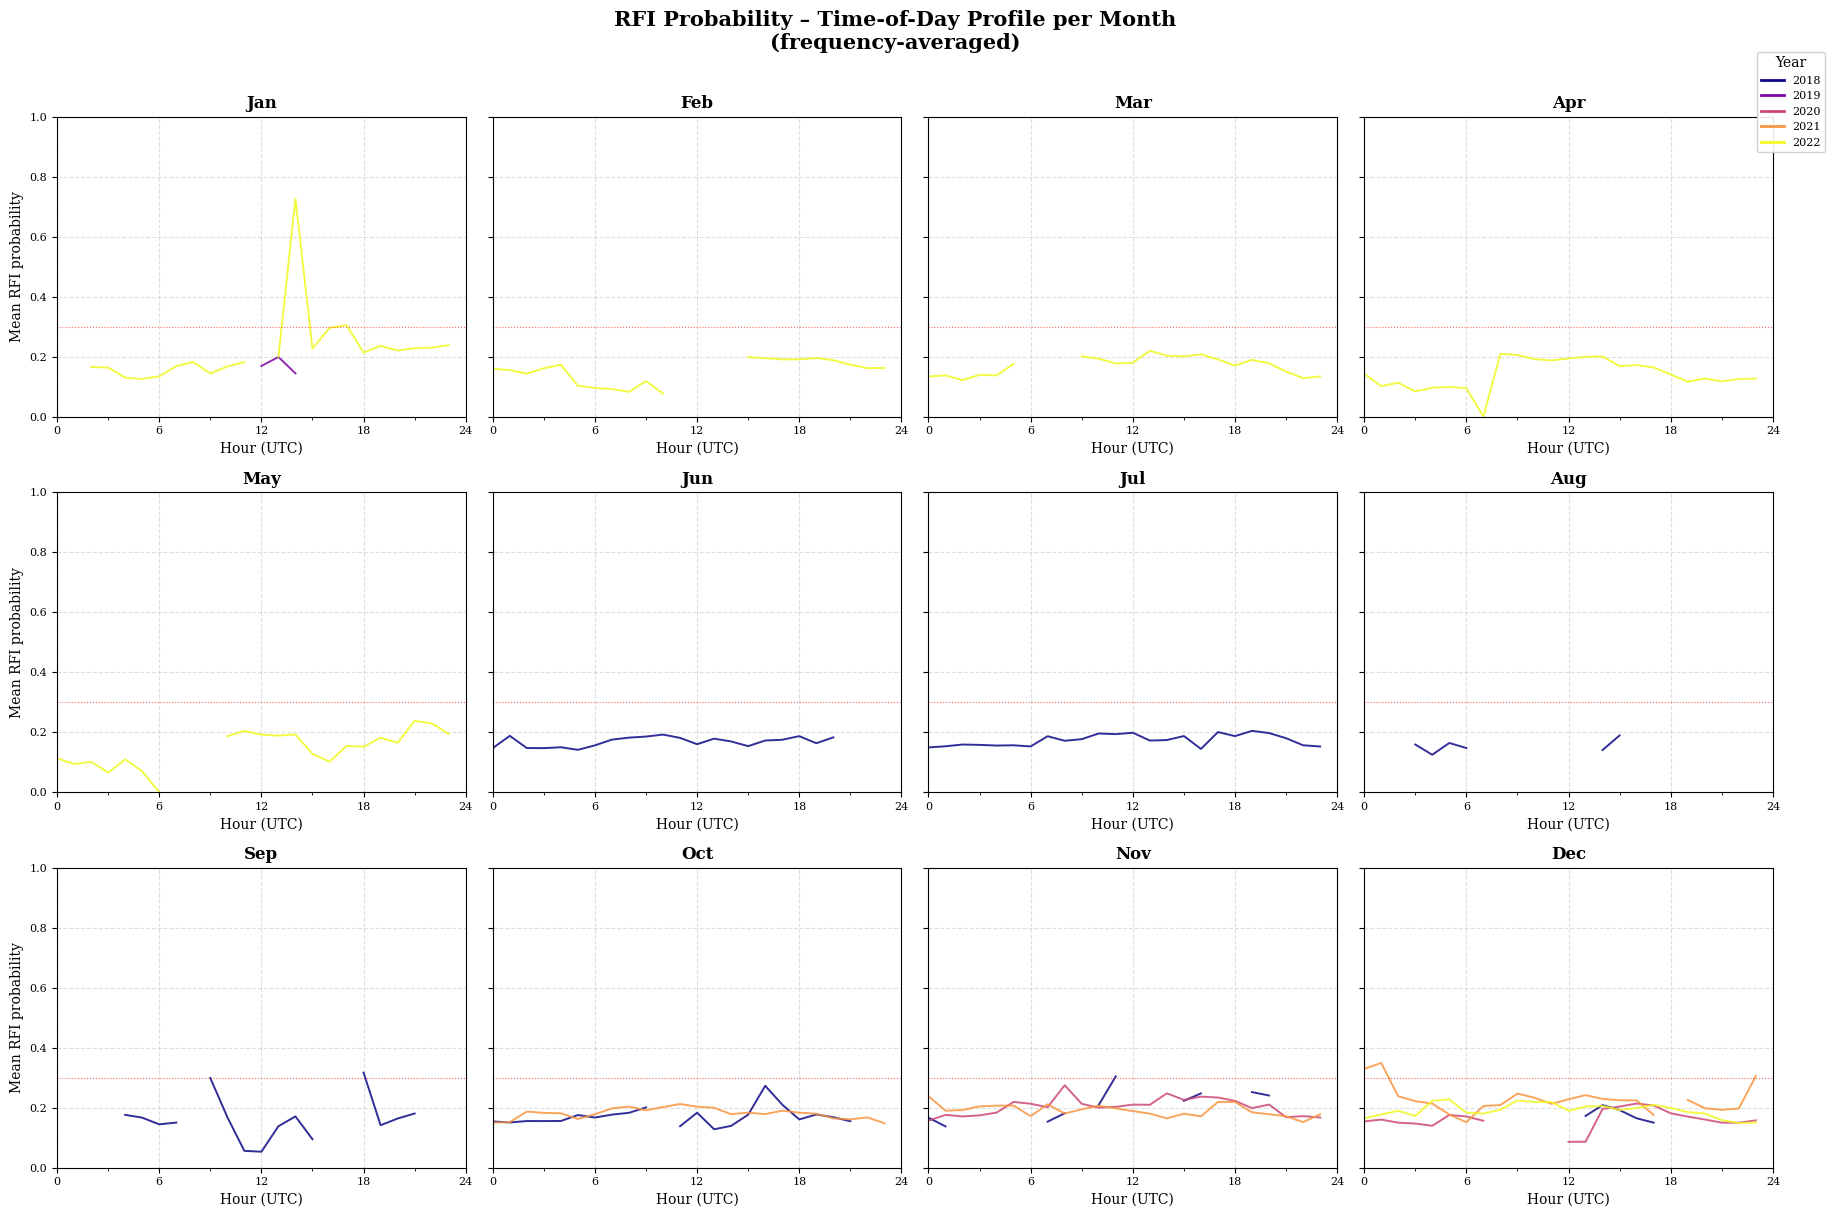

In [39]:
monthly_by_year = monthly_mean_by_year(data)
overall_monthly = overall_monthly_mean(data)
times = data[TIME_DIM].values
freqs = data[FREQ_DIM].values


plot_monthly_time_evolution(monthly_by_year, times)


### Frequency Analysis


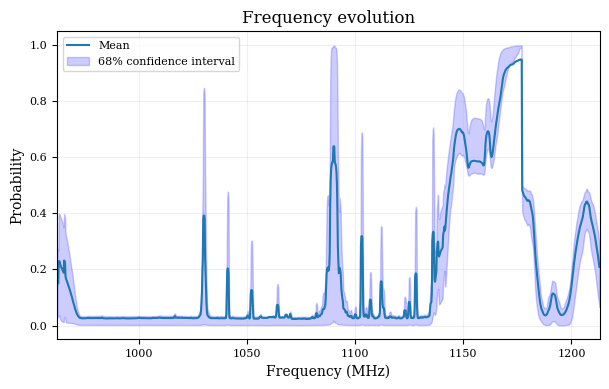

In [186]:
time_avg = weighted_data.mean(dim=("date", "time"), skipna=True)
std_data = weighted_data.std(dim=("date", "time"), skipna=True)



fig, ax = plt.subplots(figsize=(7,4))
ax.plot(frequency, time_avg, label ='Mean')


# Add the standard deviation band
ax.fill_between(
    frequency, 
    uper, 
    lower, 
    color="blue", 
    alpha=0.2, 
    label="68% confidence interval"
)
ax.set_xlim(left=962, right=1213)
ax.grid(alpha=0.2)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Probability")
ax.set_title("Frequency evolution")
ax.legend()


Text(0.5, 1.0, 'DME band RFI Heatmap')

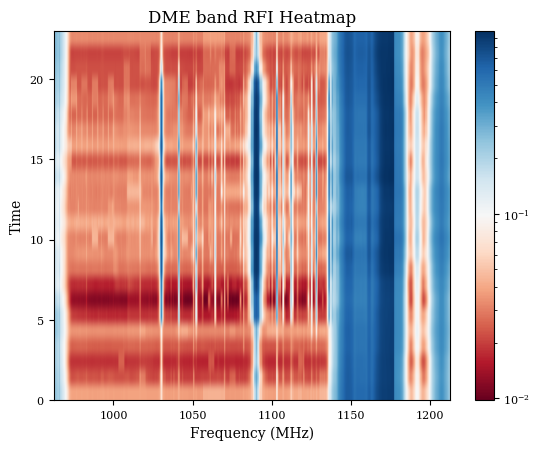

In [190]:
heat_map = data.mean(dim="date")

plt.xlabel("Frequency (MHz)")
plt.ylabel("Time")
im = plt.imshow(heat_map, aspect='auto', 
    extent=[frequency[0], frequency[-1], time[0], time[-1]],
    origin='lower', cmap='RdBu', norm=LogNorm())
cbar = plt.colorbar(im)
plt.title("DME band RFI Heatmap")


In [41]:
def plot_freq_time_heatmaps(overall_monthly: dict, times: np.ndarray, freqs: np.ndarray):
    fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True, sharey=True)
    fig.suptitle("Mean RFI Probability – Frequency vs Time-of-Day\n(all years combined)",
                 fontsize=15, fontweight="bold", y=1.01)

    vmin, vmax = 0.0, 1.0
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    im = None
    for ax, mo in zip(axes.flat, range(1, 13)):
        da_mo = overall_monthly[mo]
        if da_mo is None:
            ax.set_title(MONTH_NAMES[mo - 1])
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            continue

        # da_mo has dims (time, frequency)
        grid = da_mo.values   # shape (n_time, n_freq)
        im = ax.pcolormesh(times, freqs / 1e6, grid.T,
                           cmap=CMAP_HEATMAP, norm=norm, shading="auto")
        ax.set_title(MONTH_NAMES[mo - 1], fontweight="bold")

    for ax in axes[2]:
        ax.set_xlabel("Hour (UTC)")
    for ax in axes[:, 0]:
        ax.set_ylabel("Frequency (MHz)")

    if im is not None:
        cbar = fig.colorbar(im, ax=axes, orientation="vertical",
                            fraction=0.015, pad=0.02, label="RFI Probability")
        cbar.ax.yaxis.label.set_fontsize(11)

    plt.tight_layout()
    plt.savefig("rfi_freq_time_heatmap_by_month.png", dpi=150, bbox_inches="tight")
    print("Saved: rfi_freq_time_heatmap_by_month.png")
    plt.show()



/tmp/ipykernel_8092/1792764375.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: rfi_freq_time_heatmap_by_month.png


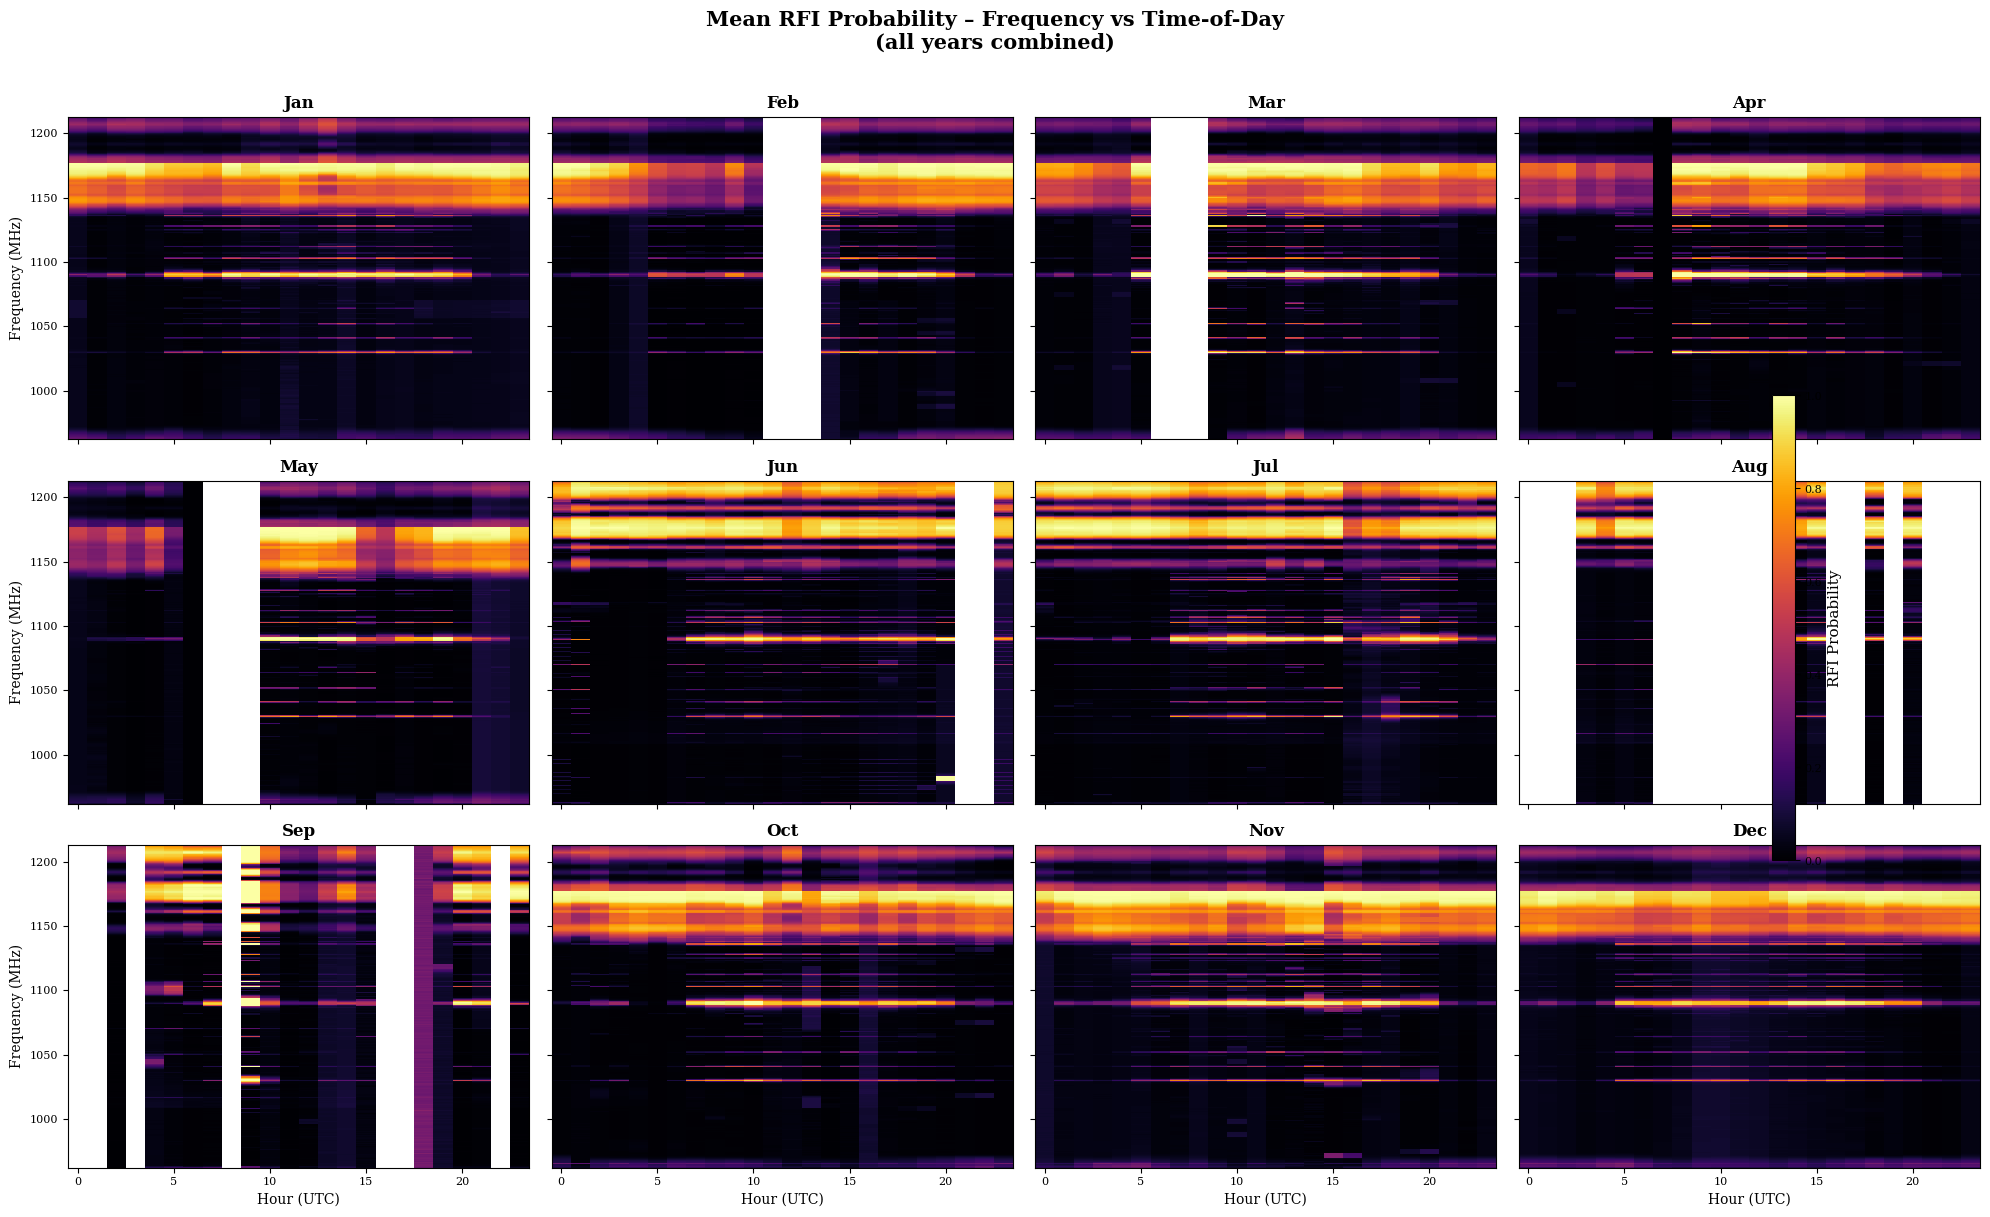

In [42]:
plot_freq_time_heatmaps(overall_monthly, times, freqs)


In [ ]:
def plot_flagged_fraction_timeseries(da: xr.DataArray):
    df = flagged_fraction(da)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.set_title(f"Fraction of (time x frequency) bins with RFI > {THRESHOLD:.0%}",
                 fontsize=13, fontweight="bold")

    for yr in YEARS:
        sub = df[df["year"] == yr].sort_values("month")
        x   = sub["month"].values
        y   = sub["flagged"].values
        ax.plot(x + (yr - 2019) * 0.1, y, "o-", label=str(yr), lw=1.5, ms=4)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_NAMES)
    ax.set_ylabel("Flagged fraction")
    ax.set_ylim(0, None)
    ax.grid(True, ls="--", alpha=0.35)
    ax.legend(title="Year", ncol=3)

    plt.tight_layout()
    plt.savefig("rfi_flagged_fraction_timeseries.png", dpi=150, bbox_inches="tight")
    print("Saved: rfi_flagged_fraction_timeseries.png")
    plt.show()



In [191]:
# plot_flagged_fraction_timeseries(data)